Домашняя контрольная работа 1

Задание: Реализовать алгоритм поиска и сопоставления ключевых точек.

Пункт 1

Получить два изображения одного и того же объекта с разных ракурсов 
(радиальное смещение камеры при смене ракурса 5–10 градусов в 
горизонтальной плоскости). По возможности использовать 
широкоугольный объектив, содержащий бочкообразную дисторсию. 

In [1]:
#Подключение библиотек
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Отдельная функция для отображение изображения (OpenCV BRG в Matplotlib RGB)
def show(img, title=None, ax=None, cmap=None):
    if ax is None:
        plt.figure(figsize=(6,4))
        ax = plt.gca()
    # Если 3 канала - переворачиваем из BGR -> RGB для plt
    if img is None:
        return
    if len(img.shape)==3 and img.shape[2]==3:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(img, cmap=cmap)
    ax.axis('off')
    if title:
        ax.set_title(title)

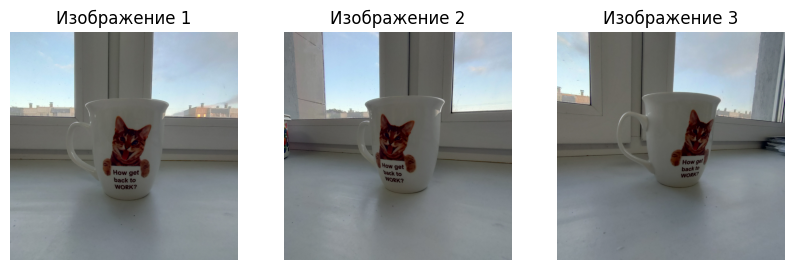

In [3]:
# Подключение изображений
img_1_path = r"D:\Programming-at-SUSU\BasicOfCV\Homeworks\KR_1\photos\1_sun.jpg"
img_2_path = r"D:\Programming-at-SUSU\BasicOfCV\Homeworks\KR_1\photos\2_sun.jpg"
img_3_path = r"D:\Programming-at-SUSU\BasicOfCV\Homeworks\KR_1\photos\3_sun.jpg"

img1 = cv2.imread(img_1_path)
img2 = cv2.imread(img_2_path)
img3 = cv2.imread(img_3_path)

#Отображение
plt.figure(figsize=(10,4))
ax1 = plt.subplot(1,3,1)
show(img1, "Изображение 1", ax=ax1)
ax2 = plt.subplot(1,3,2)
show(img2, "Изображение 2", ax=ax2)
ax3 = plt.subplot(1,3,3)
show(img3, "Изображение 3", ax=ax3)

Пункт 2

Провести шумоподавление 3 различными фильтрами 

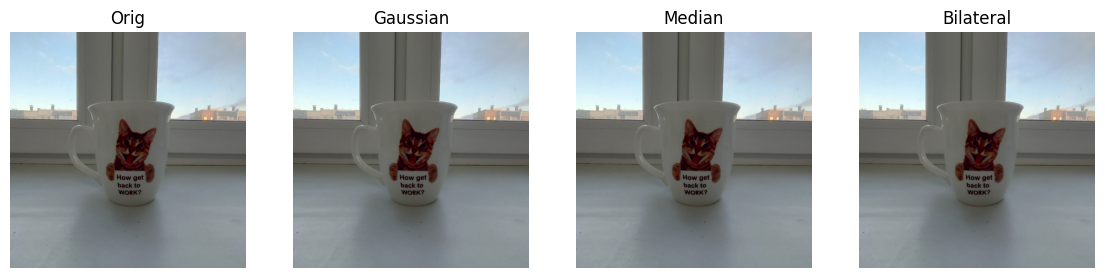

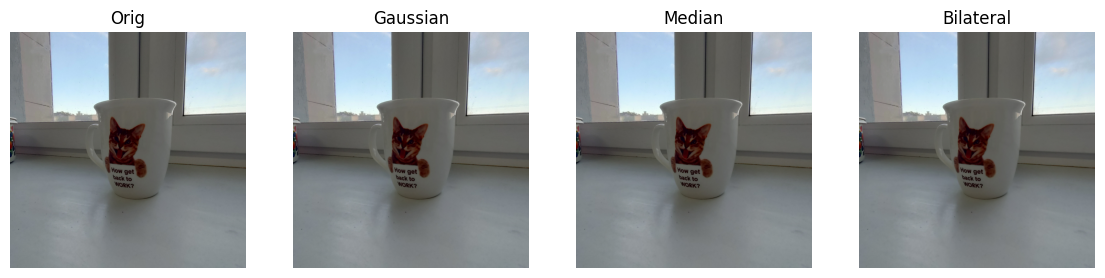

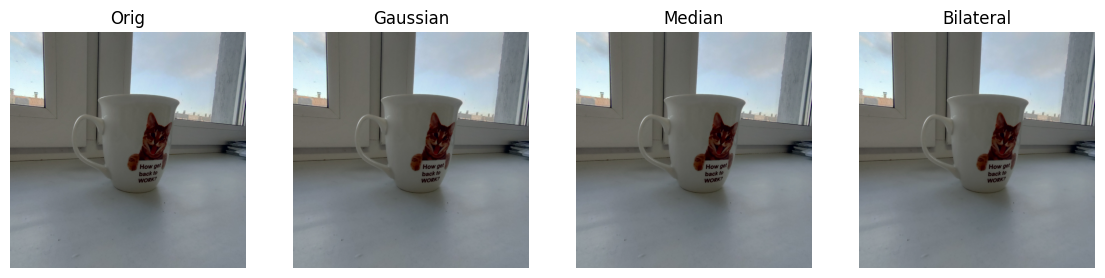

In [4]:
"""
Добавим 3 шумоподавления:
    Медианный - medainBlur
    Гауссовский - GaussianBlur
    Билатеральный фильтра - bilateralFilter
"""

#Применение медианного фильтра
M_img1 = cv2.medianBlur(img1, ksize=5)
M_img2 = cv2.medianBlur(img2, 5)
M_img3 = cv2.medianBlur(img3, 5)

G_img1 = cv2.GaussianBlur(img1, ksize=(5,5), sigmaX=1.5) 
G_img2 = cv2.GaussianBlur(img2, (5,5), 1.5)
G_img3 = cv2.GaussianBlur(img3, (5,5), 1.5)

B_img1 = cv2.bilateralFilter(img1, d=9, sigmaColor=75, sigmaSpace=75)
B_img2 = cv2.bilateralFilter(img2, 9, 75, 75)
B_img3 = cv2.bilateralFilter(img3, 9, 75, 75)

plt.figure(figsize=(14,8))
axs = [plt.subplot(1,4,i+1) for i in range(4)]
show(img1, "Orig", ax=axs[0])
show(G_img1, "Gaussian", ax=axs[1])
show(M_img1, "Median", ax=axs[2])
show(B_img1, "Bilateral", ax=axs[3])

plt.figure(figsize=(14,8))
axs = [plt.subplot(1,4,i+1) for i in range(4)]
show(img2, "Orig", ax=axs[0])
show(G_img2, "Gaussian", ax=axs[1])
show(M_img2, "Median", ax=axs[2])
show(B_img2, "Bilateral", ax=axs[3])

plt.figure(figsize=(14,8))
axs = [plt.subplot(1,4,i+1) for i in range(4)]
show(img3, "Orig", ax=axs[0])
show(G_img3, "Gaussian", ax=axs[1])
show(M_img3, "Median", ax=axs[2])
show(B_img3, "Bilateral", ax=axs[3])
plt.show()

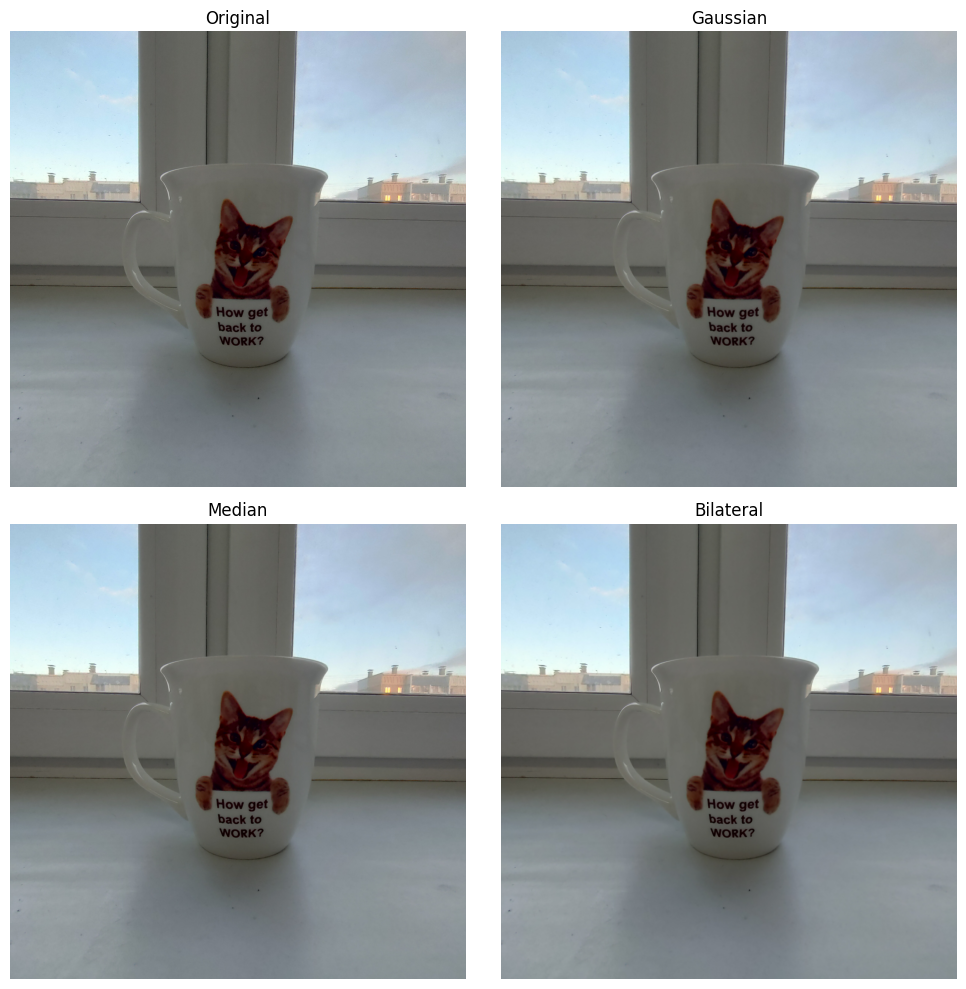

In [5]:
#Тестовая выборка картинок, чтобы увидеть разницу в шумоподавлении

Mtest_img1 = cv2.medianBlur(img1, ksize=11)
Gtest_img1 = cv2.GaussianBlur(img1, ksize=(3,3), sigmaX=5) 
Btest_img1 = cv2.bilateralFilter(img1, d=3, sigmaColor=20, sigmaSpace=40)

fig = plt.figure(figsize=(10,10))

ax1 = fig.add_subplot(2,2,1)
show(img1, "Original", ax=ax1)

ax2 = fig.add_subplot(2,2,2)
show(G_img1, "Gaussian", ax=ax2)

ax3 = fig.add_subplot(2,2,3)
show(M_img1, "Median", ax=ax3)

ax4 = fig.add_subplot(2,2,4)
show(B_img1, "Bilateral", ax=ax4)

plt.tight_layout()
plt.show()

Пункт 3

Провести коррекцию гистограммы 

In [6]:
"""
Используем формат YCrBr вместо RGB
Используем функции equalizeHist и createCLAHE
"""
def equalize_hist_color(img):
    # преобразуем в YCrCb и выровняем Y
    ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    ycrcb[:,:,0] = cv2.equalizeHist(ycrcb[:,:,0])
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

def clahe_color(img, clipLimit=2.0, tileGridSize=(8,8)):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

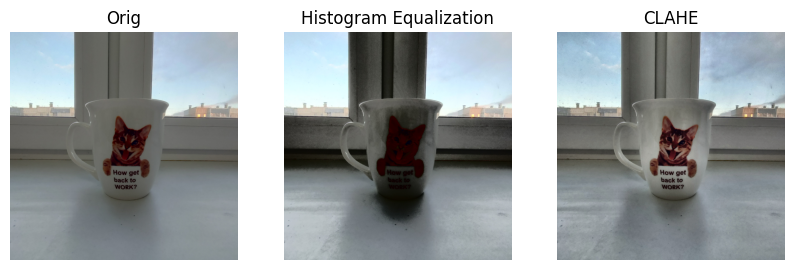

In [7]:
eq_img1 = equalize_hist_color(img1)
clahe_img1 = clahe_color(img1)

plt.figure(figsize=(10,4))
ax = plt.subplot(1,3,1); show(img1, "Orig", ax=ax)
ax = plt.subplot(1,3,2); show(eq_img1, "Histogram Equalization", ax=ax)
ax = plt.subplot(1,3,3); show(clahe_img1, "CLAHE", ax=ax)
plt.show()

Пункт 4

Провести гамма-коррекцию

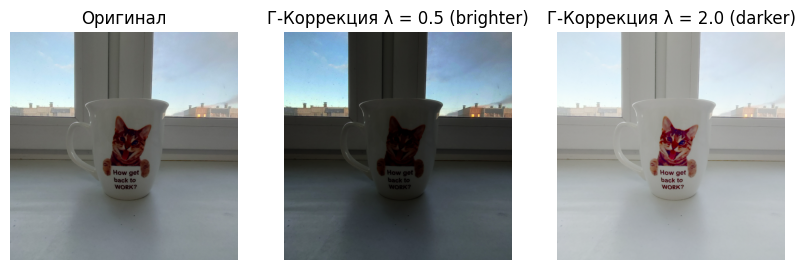

In [8]:
# Отдельная функция для гамма-коррекции
def gamma_correction(img, gamma=1.0):
    invGamma = 1.0 / gamma
    table = np.array([((i/255.0) ** invGamma) * 255 for i in np.arange(256)]).astype("uint8")
    return cv2.LUT(img, table)

g05 = gamma_correction(img1, 0.5)  # brighten
g2  = gamma_correction(img1, 2.0)  # darken

plt.figure(figsize=(10,4))
axs = [plt.subplot(1,3,i+1) for i in range(3)]
show(img1, "Оригинал", ax=axs[0])
show(g05, "Г-Коррекция λ = 0.5 (brighter)", ax=axs[1])
show(g2, "Г-Коррекция λ = 2.0 (darker)", ax=axs[2])
plt.show()

Пункт 5

1. Провести коррекцию геометрических искажений:
  
   a. Провести калибровку камеры, с которой получены изображения с помощью встроенных функций библиотеки OpenCV.
  
   b. Получить матрицу камеры и коэффициенты дисторсии.
  
   c. Провести коррекцию геометрических искажений с использованием полученных параметров.

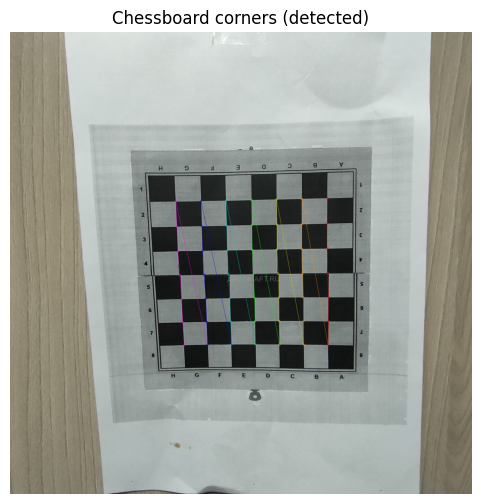

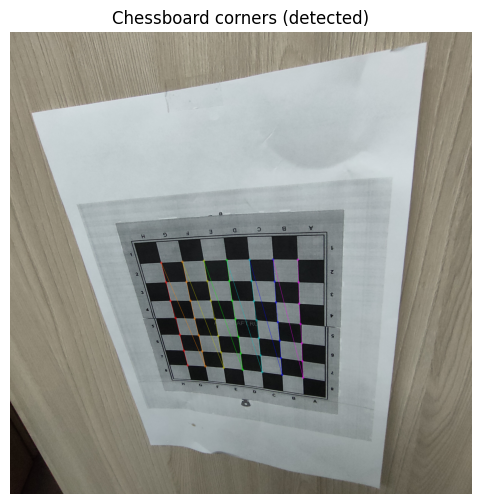

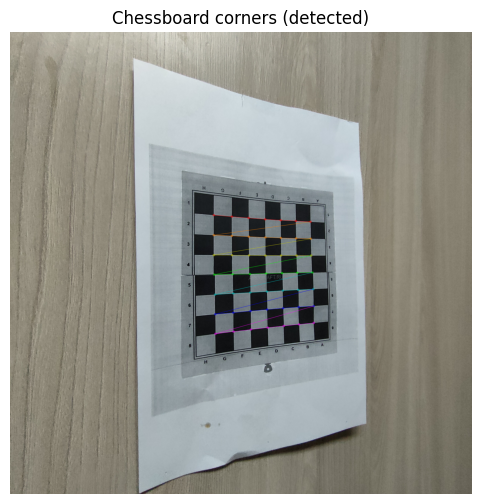

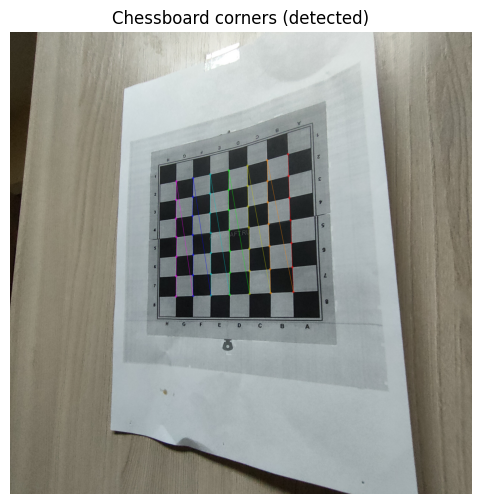

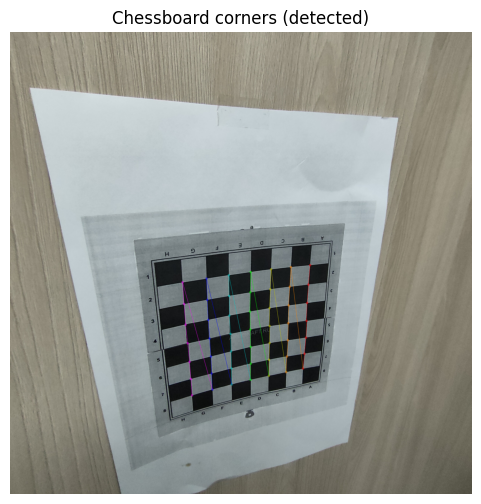

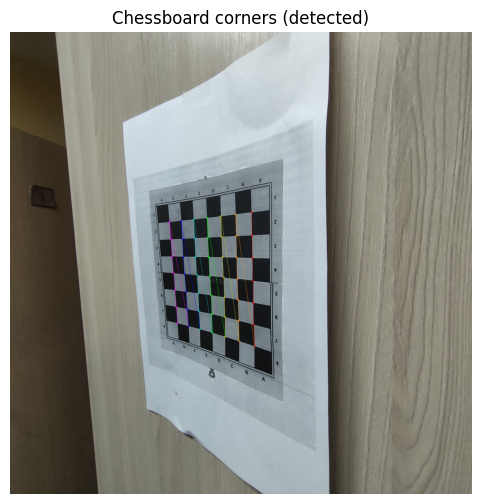

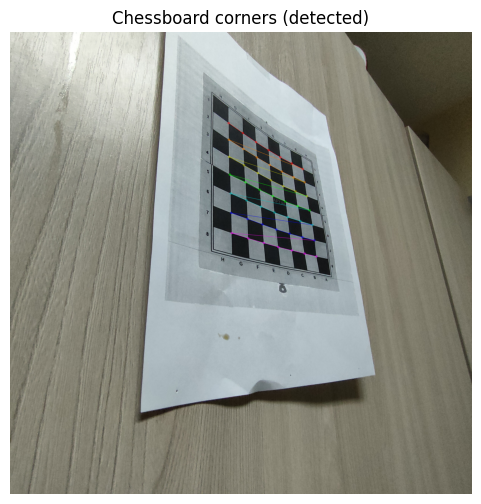

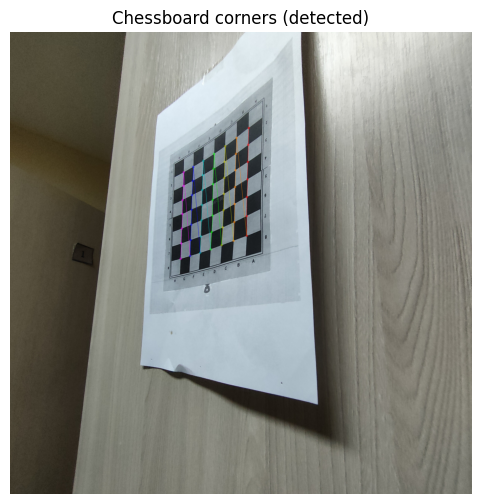

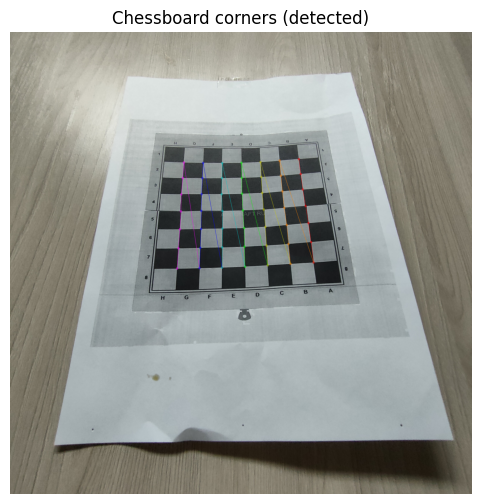

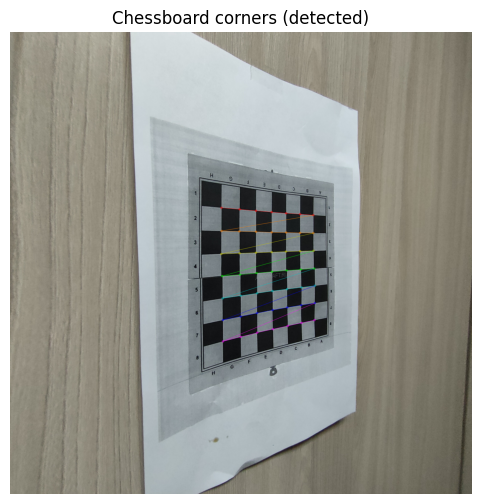

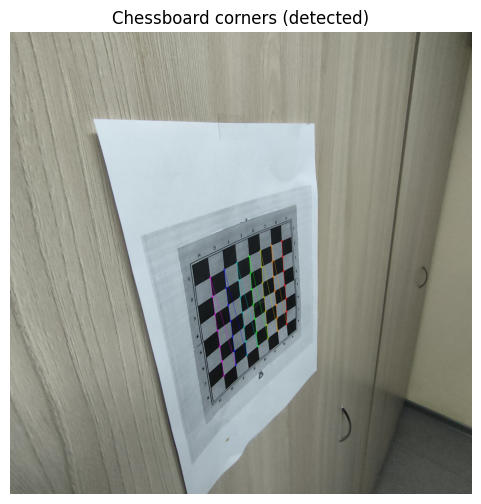

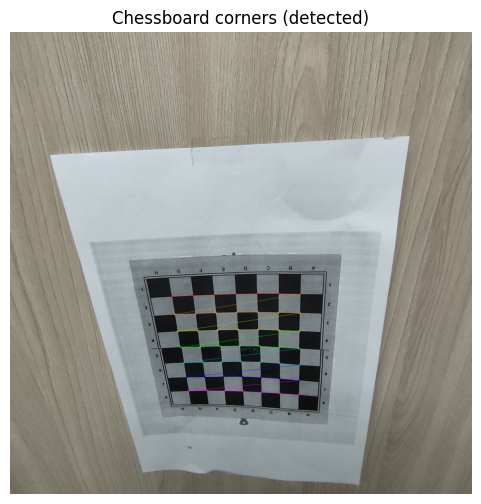

In [17]:
"""
Пункт А
Провести калибровку камеры, с которой получены изображения с помощью встроенных функций библиотеки OpenCV.
"""
import glob


#Параметры шахматной доски
chessboard_size = (7,7)  # внутренние углы
square_size = 1.0  # размер квадрата в мм - пусть пока 1 мм, т.к. не знаю размера квадрата
calib_images_dir = r"D:\Programming-at-SUSU\BasicOfCV\Homeworks\KR_1\chess"

# ====== подготовка объектных точек =======
objp = np.zeros((chessboard_size[0]*chessboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2) * square_size

objpoints = []  # 3D точки в реальном мире
imgpoints = []  # 2D точки в изображении


# ====== чтение изображений =======
images = glob.glob(calib_images_dir + '/*.jpg')

for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None)
    if ret:
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1),
                                    criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
        imgpoints.append(corners2)
        
        img_drawn = cv2.drawChessboardCorners(img, chessboard_size, corners2, ret)
        # можно отобразить:
        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(img_drawn, cv2.COLOR_BGR2RGB))
        plt.title('Chessboard corners (detected)')
        plt.axis('off')
        plt.show()
        # cv2.drawChessboardCorners(img, chessboard_size, corners2, ret)
        # cv2.imshow('corners', img); 
        # cv2.waitKey(500)

cv2.destroyAllWindows()

In [18]:
"""
Пункт Б
Получить матрицу камеры и коэффициенты дисторсии.
"""
ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
print("Камера матрицы K:\n", K)
print("Коэффициенты дисторсии(искажений):\n", dist)
print("Векторы вращения и перемещения:\n", rvecs)
print("Векторы трансляции:\n", tvecs)

Камера матрицы K:
 [[1.56770940e+03 0.00000000e+00 1.23298248e+03]
 [0.00000000e+00 1.56481739e+03 1.30368914e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Коэффициенты дисторсии(искажений):
 [[ 0.35535558 -2.07363324  0.02354512 -0.00744766  5.02082585]]
Векторы вращения и перемещения:
 (array([[ 0.17190776],
       [-0.08495913],
       [ 1.54110834]]), array([[ 0.16524766],
       [ 0.59469486],
       [-1.58559292]]), array([[ 0.01568733],
       [-0.40125282],
       [-0.02750303]]), array([[0.27070169],
       [0.43142299],
       [1.49982   ]]), array([[ 0.09624826],
       [-0.54782118],
       [ 1.45718882]]), array([[0.69471243],
       [0.46028743],
       [1.50656636]]), array([[-0.29511806],
       [-0.69542449],
       [ 0.04839426]]), array([[0.468285  ],
       [0.78301953],
       [1.3990325 ]]), array([[-0.28445619],
       [ 0.32542278],
       [ 1.51344023]]), array([[ 0.10221463],
       [-0.60171897],
       [-0.05160109]]), array([[-0.31708494],
       [-

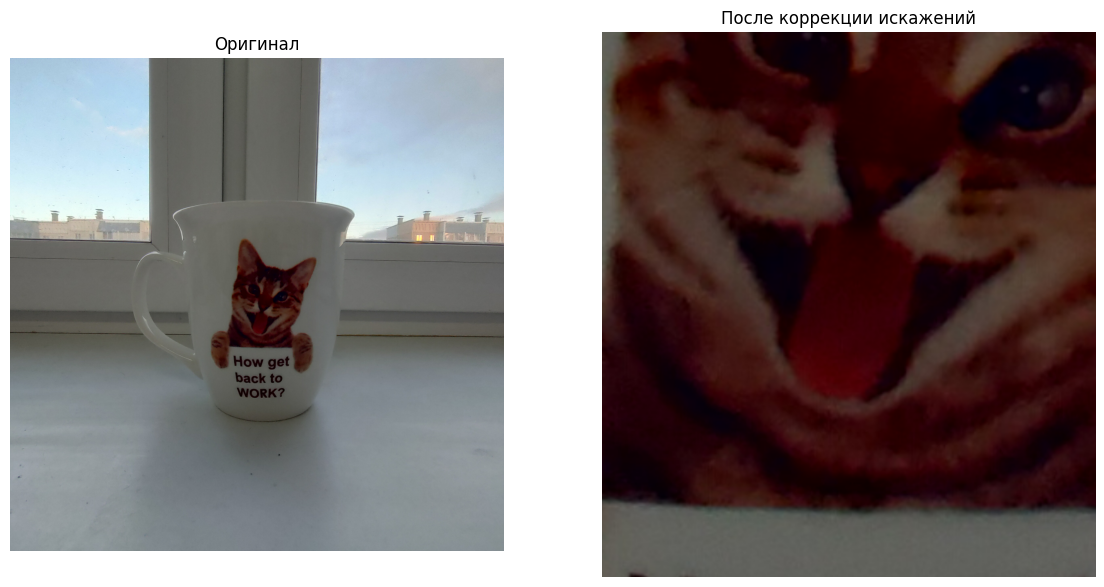

In [ ]:
"""
Пункт С
Провести коррекцию геометрических искажений с использованием полученных параметров.
"""

# ====== коррекция искажений =======
img = cv2.imread(r"D:\Programming-at-SUSU\BasicOfCV\Homeworks\KR_1\photos\1_sun.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # чтобы правильно отображалось в Matplotlib
h, w = img.shape[:2]
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w,h), 0.9, (w,h))

# "Undistort"
dst = cv2.undistort(img, K, dist, None, newcameramtx)

# Обрезка по ROI - Region Of Interest (область полезного изображения, без чёрных рамок).

#Если его добавить, то изображение будет обрезано до этой области.
# x, y, w0, h0 = roi
# dst = dst[y:y+h0, x:x+w0]

# Отобразим
# Отображаем результат
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

ax[0].imshow(img)
ax[0].set_title("Оригинал")
ax[0].axis('off')

ax[1].imshow(dst)
ax[1].set_title("После коррекции искажений")
ax[1].axis('off')

plt.show()

Пункт 6

Реализовать алгоритм поиска ключевых точек на полученном 
изображении. Ограничить отрисовку ключевых точек, 200 наиболее 
значащими ключевыми точками. 